**Aim:** make figures for Fig. 3 in the manuscript

**Author:** Yike Xie

**Date Updated:** 10 Mar 2026

In [21]:
# Load libraries
import os
import re
import sys
sys.path.append("..")
import utils
get_ipython().run_line_magic('matplotlib', 'inline')

import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D
from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42

from scipy.stats import spearmanr
# from adjustText import adjust_text

import warnings
warnings.filterwarnings("ignore")

In [20]:
fig_folder = '../../figures/manuscript_figures/figure3-4/'
data_folder = '../../data/'
res_folder = '../../tables/spatial/'

os.makedirs(fig_folder, exist_ok=True)
os.makedirs(data_folder, exist_ok=True)
os.makedirs(res_folder, exist_ok=True)

# Data Loading

## basic information

In [2]:
metadata = pd.read_excel(
    '../../figures/manuscript_figures/tables/Table1_human_donor_information.xlsx', 
    index_col=0, sheet_name='Pancreas')

tech_cols = ["snRNA-Seq", "Immunostaining", "Spatial transcriptomics", "Calcium imaging", "Slice-Seq"]
tech_mask = metadata[tech_cols].astype(str).apply(lambda s: s.str.lower().str.strip().eq("yes"))

metadata["Method"] = tech_mask.apply(
    lambda row: ", ".join([col for col, ok in row.items() if ok]),
    axis=1
)

## spatial data

In [3]:
if False:
    # this dataset includes the Local Moran's I results
    adata = sc.read_h5ad('../data/YK_raw_spatial_islet_extra_islet_c2l_annot_hq.h5ad')
    adata.obs['group'] = metadata.loc[adata.obs['sample'].str.split('-').str[0]]['group'].to_list()

In [4]:
# this is the data after neighborhood and subtype annotation
adata = sc.read_h5ad('../../data/YK_raw_spatial_ct_cst_c2l_annot_hq_neighbor_clustering_20260107.h5ad')
adata.obs['group'] = metadata.loc[adata.obs['sample'].str.split('-').str[0]]['group'].to_list()

In [5]:
# add default colors for each cell type and cell subtype

def set_adata_colors(
    adata,
    col,
    *,
    color_map=None,          # dict: category -> color (hex or named)
):
    """
    Ensure adata.obs[col] is categorical and set adata.uns[f"{col}_colors"]
    with NO None values (Scanpy requires valid colors for all categories).
    """
    if color_map is None:
        color_map = {}

    # --- ensure categorical
    s = adata.obs[col]
    cats = list(adata.obs[col].cat.categories)

    # --- big fallback palette (repeatable)
    base = []
    for cm in ["tab20", "tab20b", "tab20c"]:
        base.extend([mpl.colors.to_hex(c) for c in mpl.cm.get_cmap(cm).colors])
    # repeat if needed
    fallback = (base * ((len(cats) // len(base)) + 1))[:len(cats)]

    # --- start from fallback then override with user map
    colors = fallback[:]
    for i, c in enumerate(cats):
        if c in color_map and color_map[c] is not None:
            colors[i] = mpl.colors.to_hex(mpl.colors.to_rgb(color_map[c]))

    # --- final safety: replace any accidental 'None' or invalid strings
    colors = ["#BFBFBF" if (x is None or str(x).lower() == "none") else x for x in colors]

    adata.uns[f"{col}_colors"] = colors
    return cats, colors

annot_colors = {
    'Acinar': (1.0, 0.831, 0.624),
    'Stellate': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), # orange
    'Ductal': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), # blue
    'Endothelial': (0.5019607843137255, 0.0, 0.5019607843137255), # gray
    'Islet_endocrine': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275), # green
    'Extra_islet_endocrine': (1.0, 0.831, 0.624), # not to show extra_islet_endocrine at this stage
    # (0.5647058823529412, 0.9333333333333333, 0.5647058823529412), # lightgreen
    
    'Immune': (0.984313725490196, 0.6862745098039216, 0.8941176470588236), # pink
    'Schwann': (0.5019607843137255, 0.5019607843137255, 0.5019607843137255), # black

     'Basal_acinar': (0.7372549019607844, 0.5607843137254902, 0.5607843137254902),
     'Idling_acinar': (0.7372549019607844, 0.5607843137254902, 0.5607843137254902),
     'Intermediate_acinar': (0.9411764705882353, 0.5019607843137255, 0.5019607843137255),
     'Signaling_acinar': (0.5019607843137255, 0.0, 0.0),

     'Activated_stellates': (1.0, 0.8941176470588236, 0.7686274509803922),
     'Quiescent_stellates': (1.0, 0.5490196078431373, 0.0),

     'Basal_ductal': (0.6901960784313725, 0.7686274509803922, 0.8705882352941177),
     'Inflam_ductal_1': (0.0, 0.7490196078431373, 1.0), 
     'Inflam_ductal_2': (0.2549019607843137, 0.4117647058823529, 0.8823529411764706),
     'MUC5B+_ductal': (0.0, 0.0, 0.5019607843137255),

     'Endothelial': (0.5019607843137255, 0.0, 0.5019607843137255), 
     'Arterial_ECs': (0.8666666666666667, 0.6274509803921569, 0.8666666666666667),
     'Venous_ECs': (0.9333333333333333, 0.5098039215686274, 0.9333333333333333),
     'Capillary_ECs': (0.5019607843137255, 0.0, 0.5019607843137255),
     'Lymphatic_ECs': (0.29411764705882354, 0.0, 0.5098039215686274),

     'Islet_α': (0.5607843137254902, 0.7372549019607844, 0.5607843137254902), # medium soft green
     'Islet_β': (0.0, 0.5019607843137255, 0.0), # dark green
     'Islet_γ': (0.5647058823529412, 0.9333333333333333, 0.5647058823529412), # very light green
     'Islet_δ': (0.3333333333333333, 0.4196078431372549, 0.1843137254901961), # olive green
     'Islet_α_β': (0.2000, 0.6500, 0.3500), 
    
     'Extra_islet_β': (0.0000, 0.6500, 0.5500),   # teal-green
     'Extra_islet_non-β': (0.4000, 0.8000, 0.6500),  # soft mint-green

     'Macrophages': (0.8470588235294118, 0.7490196078431373, 0.8470588235294118),
     'Plasmablasts':  (1.0, 0.7529411764705882, 0.796078431372549),
     'T_cells': (0.8588235294117647, 0.4392156862745098, 0.5764705882352941),
     'Mast_cells': (1.0, 0.0, 1.0),

     'Schwann': (0.5019607843137255, 0.5019607843137255, 0.5019607843137255)
}

# reorder annotated cell types and subtyoes
adata.obs['annot_celltype'] = adata.obs['annot_celltype'].cat.reorder_categories(
    ['Islet_endocrine', 'Extra_islet_endocrine', 
     'Acinar', 'Ductal', 'Endothelial', 'Stellate', 
     'Immune', 'Schwann']
)
adata.obs['annot_cellsubtype'] = adata.obs['annot_cellsubtype'].cat.reorder_categories(
    ['Islet_α', 'Islet_β', 'Islet_α_β', 'Islet_γ', 'Islet_δ', 'Islet_Low quality',
     'Extra_islet_β', 'Extra_islet_non-β', 
     'Acinar', 
     'Basal_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2', 'MUC5B+_ductal', 
     'Arterial_ECs', 'Venous_ECs','Capillary_ECs', 'Lymphatic_ECs', 
     'Macrophages', 'Plasmablasts', 'T_cells', 'Mast_cells', 
     'Quiescent_stellates', 'Activated_stellates',  
     'Schwann']
)

# add build in colors of each cell type and cell subtype
set_adata_colors(adata, "annot_celltype", color_map=annot_colors)
set_adata_colors(adata, "annot_cellsubtype", color_map=annot_colors)

/tmp/ipykernel_1861084/3630293403.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base.extend([mpl.colors.to_hex(c) for c in mpl.cm.get_cmap(cm).colors])


(['Islet_α',
  'Islet_β',
  'Islet_α_β',
  'Islet_γ',
  'Islet_δ',
  'Islet_Low quality',
  'Extra_islet_β',
  'Extra_islet_non-β',
  'Acinar',
  'Basal_ductal',
  'Inflam_ductal_1',
  'Inflam_ductal_2',
  'MUC5B+_ductal',
  'Arterial_ECs',
  'Venous_ECs',
  'Capillary_ECs',
  'Lymphatic_ECs',
  'Macrophages',
  'Plasmablasts',
  'T_cells',
  'Mast_cells',
  'Quiescent_stellates',
  'Activated_stellates',
  'Schwann'],
 ['#8fbc8f',
  '#008000',
  '#33a659',
  '#90ee90',
  '#556b2f',
  '#98df8a',
  '#00a68c',
  '#66cca6',
  '#ffd49f',
  '#b0c4de',
  '#00bfff',
  '#4169e1',
  '#000080',
  '#dda0dd',
  '#ee82ee',
  '#800080',
  '#4b0082',
  '#d8bfd8',
  '#ffc0cb',
  '#db7093',
  '#ff00ff',
  '#ff8c00',
  '#ffe4c4',
  '#808080'])

In [6]:
adata_raw = adata.copy()

# all_mac as the log2 normalized version
sc.pp.filter_genes(adata, min_cells=10)
sc.pp.normalize_total(adata, target_sum=1e4, inplace=True)  # CP10K scale
sc.pp.log1p(adata, base=2) # log2 transform

/home/yike/.conda/envs/cfrna/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


- 'sample' column is the sample column
- 'barcode' (also index/obs_names) are the spatial barcodes for each spot on the curio slide
- 'x'/'y' are the spatial coords

**NOTE:** Some samples have really low quality. V32 is also a replica of V31 - this one I have removed.

## parse scRNA-Seq data

In [13]:
parse = sc.read_h5ad('../../data/parse_snRNA_annotated_YK_raw.h5ad')
parse = parse[parse.obs['Doublets'] == 'no']

In [14]:
parse_raw = parse.copy()
utils.normalizedata(parse, log1p=True)

/home/yike/.conda/envs/cfrna/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


AnnData object with n_obs × n_vars = 57858 × 38560
    obs: 'sample', 'doublet_score', 'Sex', 'BMI', 'T1D', 'Diabetes Duration', 'T2D', 'HbA1c (%)', 'HbA1c', 'Age', 'CIT (hours)', 'Cohort', 'RIN', 'Nuclei isolation', 'group', 'cell_type', 'cell_subtype', 'cell_subtype1', 'cell_subtype2', 'Doublets', 'batch'
    var: 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Doublets_colors', 'cst1_colors', 'log1p'
    obsm: 'X_pca', 'X_umap'

In [15]:
ct_palette = utils.load_ct_palette()
cst_palette = utils.load_cst_palette()

cell_types = parse.obs['cell_type'].cat.categories
cell_subtypes = parse.obs['cell_subtype'].cat.categories

groups = parse.obs['group'].cat.categories
group_colors = {
    group: sns.color_palette('husl', 5)[i] 
    for i, group in enumerate(['ND-Lean', 'ND-Obese', 'Pre-T2D', 'T1D', 'T2D'])
    }

In [16]:
cst_ticklabels = {}

for ct in cell_types:
    cst_ticklabels[ct] = ct.replace('_', ' ')

for cst in parse.obs['cell_subtype'].cat.categories:
    if '_' not in cst:
        cst_ticklabels[cst] = cst
    elif 'High_enzyme' in cst:
        cst_ticklabels[cst] = cst.split('_')[0] + ' ' + cst.split('_')[1]
    elif 'Inflam' in cst:
        cst_ticklabels[cst] = cst.split('_')[0] + ' ' + cst.split('_')[2]
    else:
        cst_ticklabels[cst] = cst.split('_')[0]

In [17]:
# cell type and cell subtype dict
unique_combinations = parse.obs[['cell_type', 'cell_subtype']].drop_duplicates()
cst_order = parse.obs['cell_subtype'].cat.categories
unique_combinations = (
    unique_combinations.sort_values(by=['cell_type', 'cell_subtype'], 
                 key=lambda col: col.map({k: i for i, k in enumerate(cst_order)}) 
                 if col.name == 'cell_subtype' else col)
)

ct_cst_dic = (
    unique_combinations
    .groupby('cell_type', observed=True)['cell_subtype']
    .apply(list)
    .to_dict()
)

# Correct way to invert: value items become keys
cst_ct_dic = {subtype: cell_type for cell_type, subtypes in ct_cst_dic.items() for subtype in subtypes}

In [18]:
def pval_to_stars(pval):
    if pval < 0.001:
        return '***'
    elif pval < 0.01:
        return '**'
    elif pval < 0.05:
        return '*'
    else:
        return 'ns'

## load preliminary data

In [7]:
# load islet features
islet_features = pd.read_csv(
    '../../tables/spatial/islet_analysis/spatial_islet_features.tsv', 
    sep='\t', index_col=1)

# distance between cell types 
dist_df = pd.read_csv(
    '../../tables/spatial/islet_analysis/spatial_islet_sharpen_distance.tsv', 
    sep='\t', index_col=0)

# load the neighbor information of endocrine spots
ct_neighbors = pd.read_csv(
    '../../tables/spatial/islet_analysis/ct_by_neighbors/ct_neighbor_combinations_with_exocrine.tsv', 
    sep='\t', index_col=0)

## functions

In [133]:
import anndataks
from statsmodels.stats.multitest import multipletests
def ks(adata, cst1, cst2, log1p=2):
    
    adata1 = adata[adata.obs['cell_subtype'].isin(cst1)]
    adata2 = adata[adata.obs['cell_subtype'].isin(cst2)]
        
    if adata1.obs.shape[0] * adata2.obs.shape[0] == 0:
        return None
    else:
        res = anndataks.compare(adata1, adata2, log1p=log1p, mode='asymp') # log2fc + -- high in adata2
        res['pval_adj'] = multipletests(res["pvalue"], method="fdr_bh")[1]
        res.index.name = 'gene'
        return res

In [134]:
import gseapy as gp

def get_pth_res(genes, gene_sets, fig_FDR, n_entities):
    
    all_results = []
    for gs in gene_sets:
        enr = gp.enrichr(
            gene_list=genes,
            gene_sets=gs,
            organism='Human',
            cutoff=False)
        res = enr.res2d.copy()
        all_results.append(res)

    df = pd.concat(all_results, ignore_index=True)

    df['Pathway identifier'] = df['Term'].str.split('(').str[-1].str[:-1]
    df['#Entities found'] = df['Overlap'].str.split('/').str[0].astype('int')
    df['#Entities total'] = df['Overlap'].str.split('/').str[1].astype('int')

    df_strict = df[
            (df['Adjusted P-value'] < fig_FDR) # < 0.1
            & (df['#Entities found'].astype('int') > n_entities)
        ]

    return df_strict

# Immunostaining data analysis

In [4]:
is_df = pd.read_csv(
    '../../tables/immunostaining/islet_shape_analysis_with_condition.csv', sep=',', index_col=0
)
is_df = is_df.dropna() # remove islets can't be annotated

is_df['islet'] = is_df['donor'].astype(str) + '_' + is_df['roi'].astype(str)
is_df = is_df.set_index('islet')
is_df['group'] = metadata.loc[is_df['donor']]['group'].tolist()

# ratio of alpha to beta proportion per islet
is_df['alpha_to_beta_ratio'] = is_df['pct_alpha'] / is_df['pct_beta']

print(f'from {len(is_df['donor'].unique())} donors get {is_df.shape[0]} islets')

# the number of cells per islet
is_df['n_alpha'] = is_df['n_cells'] / 100 * is_df['pct_alpha']
is_df['n_beta'] = is_df['n_cells'] / 100 * is_df['pct_beta']
is_df['n_delta'] = is_df['n_cells'] / 100 * is_df['pct_delta']

# normalize the proportion by the sum of (alpha + beta + delta)
norm_n = is_df['pct_alpha'] + is_df['pct_beta'] + is_df['pct_delta']
for ct in ['alpha', 'beta', 'delta']:
    is_df[f'n_pct_{ct}'] = is_df[f'pct_{ct}'] * 100 / norm_n

from 27 donors get 1801 islets


In [5]:
plot_df = is_df.copy()

# make index a plain RangeIndex
plot_df = plot_df.reset_index(drop=True)

# remove duplicated column names if any exist
plot_df = plot_df.loc[:, ~plot_df.columns.duplicated()].copy()

print(plot_df.index.is_unique)      # should be True
print(plot_df.columns.is_unique)    # should be True

True
True


## stacked bar plot - sum alpha, beta, delta to 100%

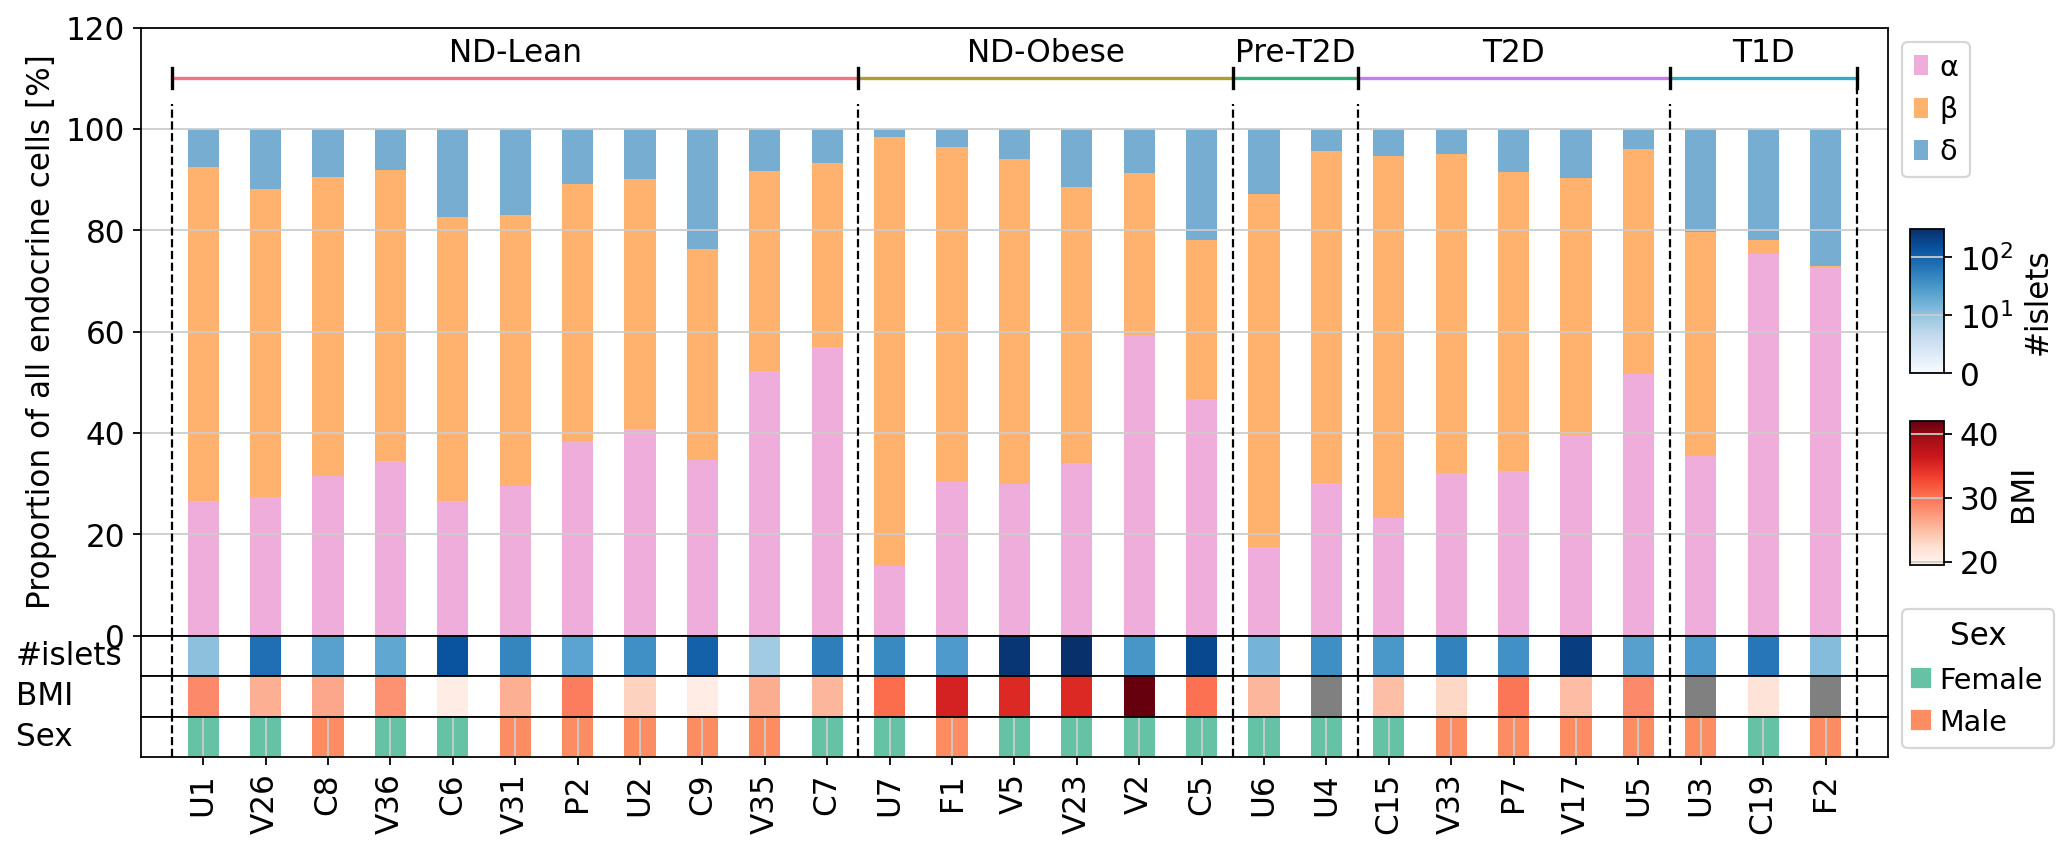

In [ ]:
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.colors as colors

# parameters for plotting
cst_col = 'cell_subtype'
palette = {
    'α': '#E377C2',
    'β': '#FF7F0E',
    'γ': '#17BECF',
    'δ': '#1F77B4',
    'α_β': '#FFD700'
    }
group_order = ['ND-Lean', 'ND-Obese', 'Pre-T2D', 'T2D', 'T1D']
plot_by = 'sample'

# compute cell abundance per donor
donors = is_df['donor'].unique().tolist()
is_abundance = pd.DataFrame(index=donors, columns=['α', 'β', 'δ'])
n_islets = {}
for donor in donors:
    is_abundance.loc[donor, 'α'] = is_df[is_df['donor'] == donor]['n_alpha'].sum()
    is_abundance.loc[donor, 'β'] = is_df[is_df['donor'] == donor]['n_beta'].sum()
    is_abundance.loc[donor, 'δ'] = is_df[is_df['donor'] == donor]['n_delta'].sum()
    n_islets[donor] = is_df[is_df['donor'] == donor].shape[0]

# normalized proportion
cst_abundance = is_abundance[is_abundance.columns[is_abundance.sum(axis=0) > 0]].T
cst_abundance_pct = cst_abundance * 100 / cst_abundance.sum(axis=0) 

# order groups and donors inside each group
group_donor_dict = {group: [] for group in group_order}
for group in group_order:
    for donor in donors:
        if metadata.loc[donor]['group'] == group:
            group_donor_dict[group].append(donor)

sample_order = []
for group in group_order:
    sample_order += cst_abundance_pct[
        group_donor_dict[group]
    ].loc['β'].sort_values(ascending=False).index.tolist()

# dataframe and cmap for plotting
cst_abundance_pct = cst_abundance_pct[sample_order]
group_numbers = {group: len(group_donor_dict[group]) for group in group_order}
cmap = sns.color_palette([palette[ct] for ct in cst_abundance_pct.index])

# fig, axs = plt.subplots(figsize=[10, 3])
fig = plt.figure(figsize=(14, 6))  # Adjust width and total height as needed
gs = gridspec.GridSpec(4, 1, height_ratios=[6, 0.4, 0.4, 0.4])  # 5:1 height ratio
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])
ax4 = fig.add_subplot(gs[3])
plt.subplots_adjust(hspace=0)

# ax1 stacked plot -- cell abundance
cst_abundance_pct.T.plot.bar(stacked=True, ax=ax1, color=cmap, alpha=0.6)
ax1.set_xlabel(None)
ax1.set_ylabel('Proportion of all endocrine cells [%]')

handles, labels = ax1.get_legend_handles_labels()
ax1.legend(
    bbox_to_anchor=[1, 1], 
    handles=handles, 
    labels=[label.replace('_', ' ') for label in labels]
    )

ax1.set_ylim(0, 120) # 250
ax1.set_xlim(-1, cst_abundance.shape[1])
x1 = -0.5
for i, group in enumerate(group_order):
    x2 = x1 + group_numbers[group]
    ax1.plot([x1, x2], [110, 110], c=group_colors[group]) # 120
    ax1.plot([x1, x1], [108, 112], c='k') # 115, 130
    ax1.text((x1 + x2) / 2, 112, group, va='bottom', ha='center')
    ax1.plot([x1, x1], [0, 105], ls='--', lw=1, c='k')
    x1 = x2
ax1.plot([x1, x1], [0, 108], ls='--', lw=1, c='k')
ax1.plot([x2, x2], [108, 112], c='k') # 115, 130

ax1.set_xticks([])
ax1.set_xticklabels([])

# number of cells
ax2.set_xlim(ax1.get_xlim())
ax2.set_ylim(0, 1)
islet_summary = np.log10([n_islets[s] for s in sample_order])
cmap2 = cm.get_cmap('Blues')
colors2 = [cmap2(islet_summary[i] / islet_summary.max()) for i in range(islet_summary.shape[0])]
for i, color in enumerate(colors2):
    ax2.bar(i, 1, color=color, width=0.5)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.text(-3, 0.5, '#islets', va='center', ha='left')

norm = colors.Normalize(vmin=0, vmax=islet_summary.max())
sm = cm.ScalarMappable(cmap=cmap2, norm=norm)
sm.set_array([])
cbar_ax2 = fig.add_axes([0.97, 0.55, 0.015, 0.15])
cbar2 = fig.colorbar(sm, cax=cbar_ax2)
cbar2.set_label('#islets')
cbar2.set_ticks([0, 1, 2])
cbar2.set_ticklabels([0, r'$10^1$', r'$10^2$'])

# BMI
bmi = metadata['BMI'].loc[sample_order]
bmi_min = metadata['BMI'].min()
bmi_max = metadata['BMI'].max()
bmi_score = ((bmi - bmi_min) / (bmi_max - bmi_min)).clip(lower=0.05).fillna(0)

ax3.set_xlim(ax1.get_xlim())
ax3.set_ylim(0, 1)
cmap3 = cm.get_cmap('Reds')
for i, s in enumerate(bmi_score):
    if s != 0:
        ax3.bar(i, 1, color=cmap3(s), width=0.5)
    else:
        ax3.bar(i, 1, color='gray', width=0.5)
ax3.set_xticks([])
ax3.set_yticks([])
ax3.text(-3, 0.5, 'BMI', va='center', ha='left')

norm = colors.Normalize(vmin=bmi_min, vmax=bmi_max)
sm = cm.ScalarMappable(cmap=cmap3, norm=norm)
sm.set_array([])

cbar_ax3 = fig.add_axes([0.97, 0.35, 0.015, 0.15])
cbar3 = fig.colorbar(sm, cax=cbar_ax3)
cbar3.set_label('BMI')
cbar3.set_ticks([20, 30, 40])

# Sex
sex = metadata['Sex'].loc[sample_order].replace({'f': 0, 'm': 1})
ax4.set_xlim(ax1.get_xlim())
ax4.set_ylim(0, 1)
for i, sample in enumerate(sample_order):
    ax4.bar(i, 1, color=sns.color_palette('Set2', 2)[sex.loc[sample]], width=0.5)
ax4.set_xticks(np.arange(len(sample_order)))
ax4.set_xticklabels(sample_order, rotation=90)
ax4.set_yticks([])
ax4.text(-3, 0.5, 'Sex', va='center', ha='left')

labels = ['Female', 'Male']
handles = []
for label, color in zip(labels, sns.color_palette('Set2')):
    handles.append(Line2D([], [], color=color, marker='s', linestyle='', markersize=8))
ax4.legend(title='Sex', labels=labels, handles=handles, bbox_to_anchor=[1, 4])

# add vertical lines
for ax in [ax2, ax3, ax4]:
    x1 = -0.5
    for i, group in enumerate(group_order):
        x2 = x1 + group_numbers[group]
        ax.plot([x1, x1], [0, 1], ls='--', lw=1, c='k')
        x1 = x2
    ax.plot([x1, x1], [0, 1], ls='--', lw=1, c='k')

# save data
fig.savefig(
    os.path.join(
        '../../figures/manuscript_figures/figure3/', 
        'Stacked_barplots_immunostaining_endocrine_cst_abundance.png'),
    dpi=300, bbox_inches='tight'
)
fig.savefig(
    os.path.join(
        '../../figures/manuscript_figures/figure3/', 
        'Stacked_barplots_immunostaining_endocrine_cst_abundance.pdf'),
    dpi=300, bbox_inches='tight'
)

## beta cell proportion

In [ ]:
# interquatile range of beta cell proportion based on abd normalization for ND-Lean donors
nd_lean_donors = plot_df[plot_df['group'] == 'ND-Lean']['donor'].unique().tolist()
beta_pcts_per_islet = plot_df[plot_df['donor'].isin(nd_lean_donors)]['n_pct_beta'].fillna(0)
np.percentile(beta_pcts_per_islet, 25), np.percentile(beta_pcts_per_islet, 75)

(33.333333333333336, 80.69887429643528)

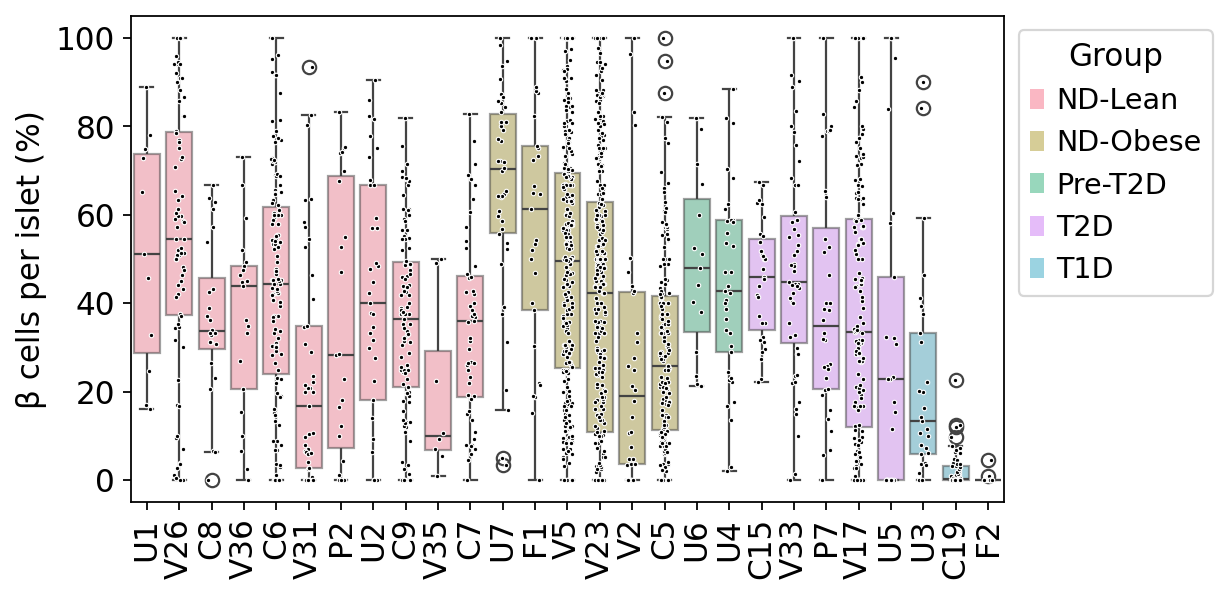

In [ ]:
# the distribution of beta cell proportion per islet of each donor, donors are sorted inside each group 
# 'n_pct_{ct} is for normalized proportion
# 'pct_{ct} is the original annotation
sc.settings.set_figure_params()
from matplotlib.patches import Patch

group_order = ['ND-Lean', 'ND-Obese', 'Pre-T2D', 'T2D', 'T1D']
group_colors = {
    group: sns.color_palette('husl', 5)[i] 
    for i, group in enumerate(['ND-Lean', 'ND-Obese', 'Pre-T2D', 'T1D', 'T2D'])
    }
plot_by = 'sample'

# compute cell abundance per donor
donors = is_df['donor'].unique().tolist()
is_abundance = pd.DataFrame(index=donors, columns=['α', 'β', 'δ'])
n_islets = {}
for donor in donors:
    is_abundance.loc[donor, 'α'] = is_df[is_df['donor'] == donor]['n_alpha'].sum()
    is_abundance.loc[donor, 'β'] = is_df[is_df['donor'] == donor]['n_beta'].sum()
    is_abundance.loc[donor, 'δ'] = is_df[is_df['donor'] == donor]['n_delta'].sum()
    n_islets[donor] = is_df[is_df['donor'] == donor].shape[0]

# normalized proportion
cst_abundance = is_abundance[is_abundance.columns[is_abundance.sum(axis=0) > 0]].T
cst_abundance_pct = cst_abundance * 100 / cst_abundance.sum(axis=0) 

# order groups and donors inside each group
group_donor_dict = {group: [] for group in group_order}
for group in group_order:
    for donor in donors:
        if metadata.loc[donor]['group'] == group:
            group_donor_dict[group].append(donor)

sample_order = []
palette = {}
for group in group_order:
    sample_order += cst_abundance_pct[
        group_donor_dict[group]
    ].loc['β'].sort_values(ascending=False).index.tolist()
    palette.update({i: group_colors[group] for i in group_donor_dict[group]})

# plotting
fig, ax = plt.subplots(figsize=(7, 4))

sns.boxplot(
    data=plot_df,
    x='donor',
    y='pct_beta',
    ax=ax,
    order=sample_order,
    palette=palette
)
for patch in ax.patches:
    patch.set_alpha(0.5)

sns.stripplot(
    data=plot_df,
    x='donor',
    y='pct_beta',
    size=2,
    edgecolor='w',
    linewidth=0.5,
    jitter=0.15,
    ax=ax,
    order=sample_order,
    color='k'
)

handles = [
    Patch(facecolor=group_colors[group], label=group, alpha=0.5)
    for group in group_order
]
ax.legend(
    handles=handles,
    title="Group",
    bbox_to_anchor=(1, 1),
    loc='best',
    frameon=True
)

ax.set_xlabel(None)
ax.set_ylabel(fr'β cells per islet (%)')
ax.set_xticklabels([label.get_text() for label in ax.get_xticklabels()], rotation=90)
ax.grid(False)

fig.savefig(
    os.path.join(
        fig_folder,
        f'pct_beta_per_islet_by_sample.png'
    ), 
    dpi=300, bbox_inches='tight'
)

fig.savefig(
    os.path.join(
        fig_folder,
        f'pct_beta_per_islet_by_sample.pdf'
    ), 
    dpi=300, bbox_inches='tight'
)

## cell abundance (immunostaining, scRNA-Seq, spatial transcriptomicsm)

In [ ]:
# # compute cell abundance per donor by immunostaining
# # -- this is the way normalized by the sum of alpha, beta, delta cells

# donors = is_df['donor'].unique().tolist()
# staining_islet_abundance = pd.DataFrame(index=donors, columns=['α', 'β', 'δ'])

# for donor in donors:
#     staining_islet_abundance.loc[donor, 'α'] = is_df[is_df['donor'] == donor]['n_alpha'].sum()
#     staining_islet_abundance.loc[donor, 'β'] = is_df[is_df['donor'] == donor]['n_beta'].sum()
#     staining_islet_abundance.loc[donor, 'δ'] = is_df[is_df['donor'] == donor]['n_delta'].sum()

# staining_cst_abundance = staining_islet_abundance[
#     staining_islet_abundance.columns[staining_islet_abundance.sum(axis=0) > 0]].T
# staining_cst_abundance_pct = (staining_cst_abundance * 100 / staining_cst_abundance.sum(axis=0)).T
# staining_cst_abundance_pct['group'] = metadata.loc[staining_cst_abundance_pct.index]['group']

In [65]:
# compute cell abundance per donor by immunostaining
# # -- this is the way calculated based on Kajsa's annotation

donors = is_df['donor'].unique().tolist()
staining_islet_abundance = pd.DataFrame(index=donors, columns=['α', 'β', 'δ'])
staining_cst_abundance_pct = pd.DataFrame(index=donors, columns=['α', 'β', 'δ'])

for donor in donors:
    n_total = is_df[is_df['donor'] == donor]['n_cells'].sum()

    for ct_i, ct_j in zip(['α', 'β', 'δ'], ['alpha', 'beta', 'delta']):
        n_ct = is_df[is_df['donor'] == donor][f'n_{ct_j}'].sum()
        staining_islet_abundance.loc[donor, ct_i] = n_ct
        staining_cst_abundance_pct.loc[donor, ct_i] = n_ct * 100 / n_total

staining_cst_abundance = staining_islet_abundance[
    staining_islet_abundance.columns[staining_islet_abundance.sum(axis=0) > 0]].T
staining_cst_abundance_pct['group'] = metadata.loc[staining_cst_abundance_pct.index]['group']

In [22]:
# compute cell abundance per donor by immunostaining
# # -- this is the way calculated based on abd annotation

donors = is_df['donor'].unique().tolist()
staining_islet_abundance2 = pd.DataFrame(index=donors, columns=['α', 'β', 'δ'])
staining_cst_abundance_pct2 = pd.DataFrame(index=donors, columns=['α', 'β', 'δ'])

for donor in donors:
    n_total = is_df[is_df['donor'] == donor][['n_alpha', 'n_beta', 'n_delta']].sum().sum()

    for ct_i, ct_j in zip(['α', 'β', 'δ'], ['alpha', 'beta', 'delta']):
        n_ct = is_df[is_df['donor'] == donor][f'n_{ct_j}'].sum()
        staining_islet_abundance2.loc[donor, ct_i] = n_ct
        staining_cst_abundance_pct2.loc[donor, ct_i] = n_ct * 100 / n_total

staining_cst_abundance2 = staining_islet_abundance2[
    staining_islet_abundance2.columns[staining_islet_abundance2.sum(axis=0) > 0]].T
staining_cst_abundance_pct2['group'] = metadata.loc[staining_cst_abundance_pct2.index]['group']

In [19]:
# compute cell abundance per donor by spatial transcriptomics

for ct in ['alpha', 'beta', 'gamma', 'delta']:
    islet_features[f'n_{ct}'] = islet_features['n_beads'] * islet_features[f'{ct}_frac']

donors = islet_features['sample'].unique().tolist()
spatial_islet_abundance = pd.DataFrame(index=donors, columns=['α', 'β', 'γ', 'δ'])

for donor in donors:
    spatial_islet_abundance.loc[donor, 'α'] = islet_features[
        islet_features['sample'] == donor]['n_alpha'].sum() 
    spatial_islet_abundance.loc[donor, 'β'] = islet_features[
        islet_features['sample'] == donor]['n_beta'].sum()
    spatial_islet_abundance.loc[donor, 'δ'] = islet_features[
        islet_features['sample'] == donor]['n_delta'].sum()
    spatial_islet_abundance.loc[donor, 'γ'] = islet_features[
        islet_features['sample'] == donor]['n_gamma'].sum()

spatial_cst_abundance = spatial_islet_abundance[
    spatial_islet_abundance.columns[spatial_islet_abundance.sum(axis=0) > 0]].T
spatial_cst_abundance_pct = (spatial_cst_abundance * 100 / spatial_cst_abundance.sum(axis=0)).T
spatial_cst_abundance_pct['group'] = metadata.loc[
    spatial_cst_abundance_pct.index.str.split('-').str[0]
    ]['group'].tolist()
spatial_cst_abundance_pct.drop(index=['U6-slice'], inplace=True)

In [23]:
# compute cell abundance per donor by snRNA-Seq (parse)
parse_islet = parse[parse.obs['cell_type'] == 'Endocrine'].copy()

parse_cst_abundance = pd.crosstab(parse_islet.obs["cell_subtype"], parse_islet.obs["sample"])
parse_cst_abundance_pct = (parse_cst_abundance * 100/ parse_cst_abundance.sum()).T
parse_cst_abundance_pct['group'] = metadata.loc[parse_cst_abundance_pct.index]['group']

In [27]:
# Exclude T1D entirely for the following plots
valid_parse = parse_cst_abundance_pct.index.tolist()
valid_staining = staining_cst_abundance_pct2.index.tolist()
valid_spatial = spatial_cst_abundance_pct.index.tolist()

In [25]:
from scipy.stats import mannwhitneyu

def pairwise_stats_with_median_change(
    df,
    x_col='variable',
    y_col='value',
    pairs=None,
    alternative='two-sided'
):
    results = []

    for a, b in pairs:
        A = df.loc[df[x_col] == a, y_col].dropna().to_numpy()
        B = df.loc[df[x_col] == b, y_col].dropna().to_numpy()

        if len(A) == 0 or len(B) == 0:
            results.append({
                'group1': a,
                'group2': b,
                'n1': len(A),
                'n2': len(B),
                'median1': np.nan,
                'median2': np.nan,
                'p_value': np.nan,
                'significant_0.05': False,
                'pct_median_change': np.nan,
            })
            continue

        stat, p = mannwhitneyu(A, B, alternative=alternative)

        med_a = np.median(A)
        med_b = np.median(B)

        denom = np.mean([med_a, med_b])
        if denom == 0:
            pct_change = np.nan
        else:
            # pct_change = (med_a - med_b) / denom * 100
            pct_change = (med_a - med_b) # change to just absolute difference

        results.append({
            'group1': a,
            'group2': b,
            'n1': len(A),
            'n2': len(B),
            'median1': med_a,
            'median2': med_b,
            'p_value': p,
            'significant_0.05': p < 0.05,
            'pct_median_change': pct_change,
        })

    return pd.DataFrame(results)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ST vs. snRNA: Mann-Whitney-Wilcoxon test two-sided, P_val:3.087e-02 U_stat=1.430e+02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ST vs. snRNA: Mann-Whitney-Wilcoxon test two-sided, P_val:2.750e-03 U_stat=3.100e+01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

IH vs. snRNA: Mann-Whitney-Wilcoxon test two-sided, P_val:1.269e-02 U_stat=1.390e+02


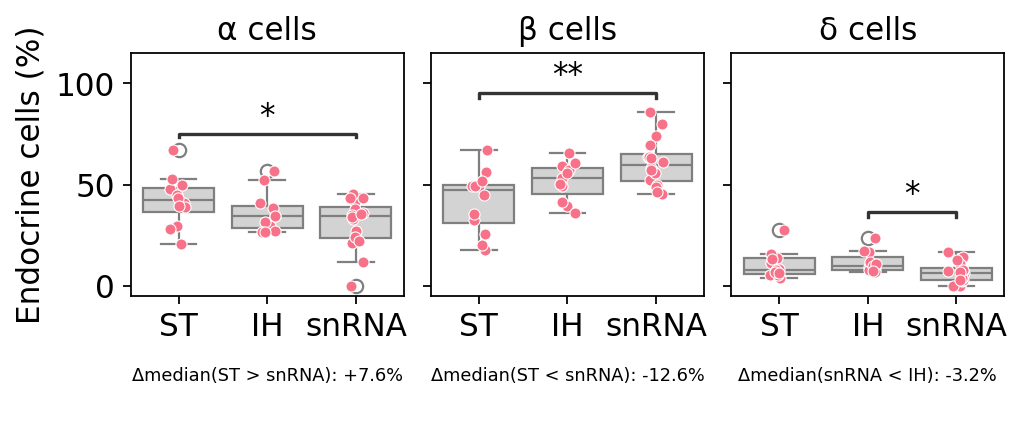

In [30]:
# only including ND-Lean

from statannotations.Annotator import Annotator

all_samples = list(set(valid_parse) | set(valid_staining) | set(valid_spatial))
all_samples = [s for s in all_samples if metadata.loc[s, 'group'] == 'ND-Lean']

fig, axs = plt.subplots(1, 3, figsize=[7, 2], sharey=True)
axs = axs.ravel()
plt.subplots_adjust(wspace=0.1)

for ax, ct in zip(axs, ['α', 'β', 'δ']): # , 'γ'
    ct_plot_df = pd.DataFrame(index=all_samples)
    ct_plot_df['group'] = metadata.loc[all_samples, 'group']
    
    ct_plot_df['ST'] = spatial_cst_abundance_pct.loc[
        list(set(valid_spatial) & set(all_samples)), ct]
    ct_plot_df['IH'] = staining_cst_abundance_pct2.loc[
        list(set(valid_staining) & set(all_samples)), ct] if ct != 'γ' else np.nan
    ct_plot_df['snRNA'] = parse_cst_abundance_pct.loc[
        list(set(valid_parse) & set(all_samples)), ct]

    ct_plot_df = ct_plot_df.melt(id_vars=['group'])
    ct_plot_df['value'] = pd.to_numeric(ct_plot_df['value'], errors='coerce')
    ct_plot_df = ct_plot_df.dropna(subset=['value'])

    sns.boxplot(
        data=ct_plot_df,
        x='variable',
        y='value',
        color='lightgray',
        ax=ax
    )

    sns.stripplot(
        data=ct_plot_df,
        x='variable',
        y='value',
        color=group_colors['ND-Lean'],
        edgecolor='w',
        linewidth=0.5,
        ax=ax
    )

    pairs = [
        ('ST', 'IH'),
        ('ST', 'snRNA'),
        ('snRNA', 'IH')
        ]

    # label significance stars of Man-Whitney U in the plot
    annotator = Annotator(
        ax, pairs,
        data=ct_plot_df,
        x='variable', y='value',
        # orient='h'
    )
    annotator.configure(
        test='Mann-Whitney',
        text_format='star',
        hide_non_significant=True,
        # loc='outside'
    )
    annotator.apply_and_annotate()

    # show the difference between two groups
    stats_df = pairwise_stats_with_median_change(
        ct_plot_df,
        x_col='variable',
        y_col='value',
        pairs=pairs,
    )

    sig_stats = stats_df.loc[stats_df['significant_0.05']].copy()

    # Get category order from plot
    xticks = ax.get_xticks()
    xticklabels = [t.get_text() for t in ax.get_xticklabels()]
    xpos = dict(zip(xticklabels, xticks))

    # Starting height for annotations
    y_max = ct_plot_df['value'].max()
    y_min = ct_plot_df['value'].min()
    y_offset = (y_max - y_min) * 0.1

    label = ''
    for i, row in stats_df.iterrows():
        if not row['significant_0.05']:
            continue

        g1 = row['group1']
        g2 = row['group2']
        pct = row['pct_median_change']

        x1 = xpos[g1]
        x2 = xpos[g2]
        x_center = (x1 + x2) / 2

        # stack text higher for each pair
        y = -40
        relation = ">" if pct > 0 else "<" if pct < 0 else "="
        label_i = f"Δmedian({g1} {relation} {g2}): {pct:+.1f}%"
        label += label_i + '\n'

    ax.text(
        1,
        y,
        label,
        ha="center",
        va="top",
        fontsize=8
    )

    # other settings
    ax.set_xlabel('')
    ax.set_title(f'{ct} cells')
    ax.grid(False)

    ax.set_ylim([-5, 115])

    if ax == axs[0]:
        ax.set_ylabel(f'Endocrine cells (%)')
    else:
        ax.set_ylabel('')

    ax.legend().remove()

plt.show()

fig.savefig(
    os.path.join(fig_folder, 'pct_per_donor_by_modalities_all_cts_ND-Lean_2_abd_normalization.png'),
    bbox_inches='tight', dpi=300
)
fig.savefig(
    os.path.join(fig_folder, 'pct_per_donor_by_modalities_all_cts_ND-Lean_2_abd_normalization.pdf'),
    bbox_inches='tight', dpi=300
)

## distribution of endocrine cell type proportion per islet between ST and IH

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ST vs. IH: Mann-Whitney-Wilcoxon test two-sided, P_val:6.393e-43 U_stat=1.020e+05


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ST vs. IH: Mann-Whitney-Wilcoxon test two-sided, P_val:2.962e-16 U_stat=7.088e+04
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ST vs. IH: Mann-Whitney-Wilcoxon test two-sided, P_val:3.683e-03 U_stat=5.835e+02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ST vs. IH: Mann-Whitney-Wilcoxon test two-sided, P_val:8.528e-05 U_stat=2.296e+04
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p

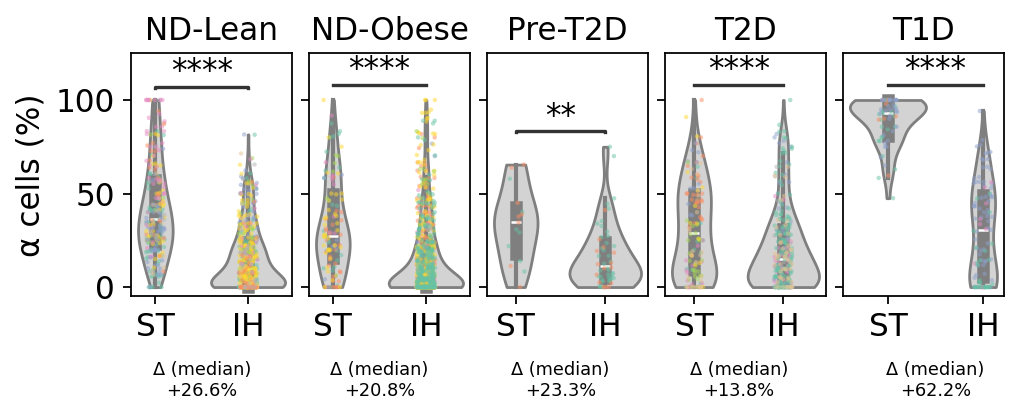

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ST vs. IH: Mann-Whitney-Wilcoxon test two-sided, P_val:4.059e-02 U_stat=1.619e+04
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04

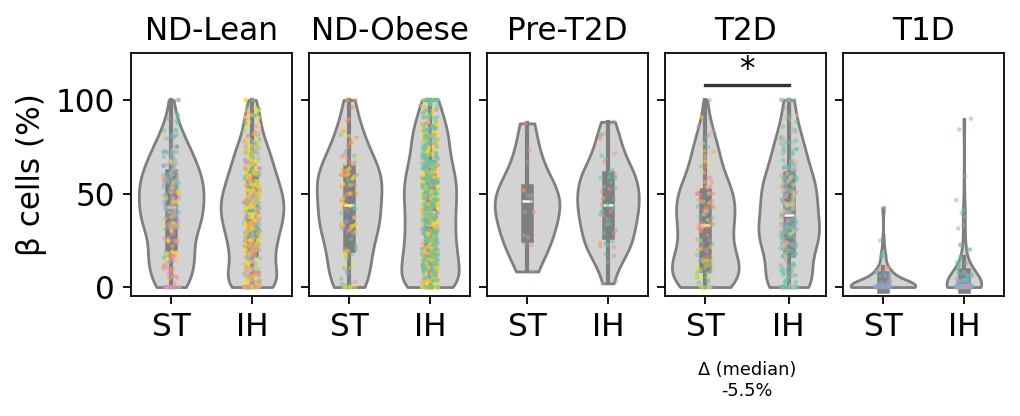

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ST vs. IH: Mann-Whitney-Wilcoxon test two-sided, P_val:7.751e-03 U_stat=5.554e+04
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04

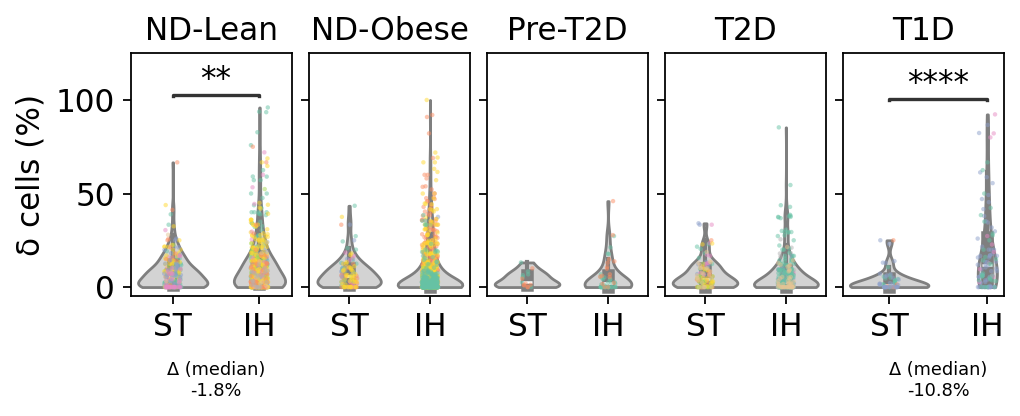

In [93]:
from statannotations.Annotator import Annotator

group_order = ['ND-Lean', 'ND-Obese', 'Pre-T2D', 'T2D', 'T1D']
all_samples = list(set(valid_staining) | set(valid_spatial))

for ct, feature in zip(['α', 'β', 'δ'], ['alpha_frac', 'beta_frac', 'delta_frac']):
    fig, axs = plt.subplots(1, len(group_order), figsize=[7, 2], sharey=True)
    plt.subplots_adjust(wspace=0.1)

    for ax, group in zip(axs, group_order):
        filtered_samples = [s for s in all_samples if metadata.loc[s, 'group'] == group]
        variables, values, sample_ids = [], [], []
        ct_plot_df = pd.DataFrame()

        # spatial transcriptomics
        st_mask = islet_features['sample'].isin(filtered_samples)
        variables += ['ST'] * st_mask.sum()
        values += (islet_features[st_mask][feature] * 100).tolist()
        sample_ids += islet_features[st_mask]['sample'].tolist()

        # staining
        ih_mask = is_df['donor'].isin(filtered_samples)
        variables += ['IH'] * ih_mask.sum()
        values += is_df[ih_mask][f"pct_{feature.split('_')[0]}"].tolist()
        sample_ids += is_df[ih_mask]['donor'].tolist()

        ct_plot_df['variable'] = variables
        ct_plot_df['value'] = values
        ct_plot_df['sample'] = sample_ids

        sns.violinplot(
            data=ct_plot_df,
            x='variable',
            y='value',
            color='lightgray',
            order=['ST', 'IH'],
            cut=0,
            ax=ax
        )

        sns.stripplot(
            data=ct_plot_df,
            x='variable',
            y='value',
            order=['ST', 'IH'],
            hue='sample', 
            # color=group_colors[group],
            palette='Set2',
            # edgecolor='w',
            # linewidth=0.5,
            alpha=0.5,
            size=2,
            ax=ax
        )

        pairs = [
            ('ST', 'IH'),
            ]

        # label significance stars of Man-Whitney U in the plot
        annotator = Annotator(
            ax, pairs,
            data=ct_plot_df,
            x='variable', y='value',
        )
        annotator.configure(
            test='Mann-Whitney',
            text_format='star',
            hide_non_significant=True,
            text_offset=-0.02,
            line_offset=0.003,
            line_height=0.003,
        )
        annotator.apply_and_annotate()

        # show the difference between two groups
        stats_df = pairwise_stats_with_median_change(
            ct_plot_df,
            x_col='variable',
            y_col='value',
            pairs=pairs,
        )

        sig_stats = stats_df.loc[stats_df['significant_0.05']].copy()
        
        # Get category order from plot
        xticks = ax.get_xticks()
        xticklabels = [t.get_text() for t in ax.get_xticklabels()]
        xpos = dict(zip(xticklabels, xticks))

        # Starting height for annotations
        y_max = ct_plot_df['value'].max()
        y_min = ct_plot_df['value'].min()
        y_offset = (y_max - y_min) * 0.1

        for i, row in stats_df.iterrows():
            if not row['significant_0.05']:
                continue

            g1 = row['group1']
            g2 = row['group2']
            pct = row['pct_median_change']

            x1 = xpos[g1]
            x2 = xpos[g2]
            x_center = (x1 + x2) / 2

            # stack text higher for each pair
            relation = ">" if pct > 0 else "<" if pct < 0 else "="
            # label = f"Δ (median): {pct:+.1f}%\n({g1} {relation} {g2})"
            label = f"Δ (median)\n{pct:+.1f}%"

            ax.text(
                0.5,
                -50,
                label,
                ha="center",
                va="center",
                fontsize=8
            )

        # other settings
        ax.set_xlabel('')
        ax.set_title(group)
        ax.grid(False)

        ax.set_ylim([-5, 125])

        if ax == axs[0]:
            ax.set_ylabel(f'{ct} cells (%)')
        else:
            ax.set_ylabel('')

        ax.set_xticklabels(['ST', 'IH'])

        ax.legend().remove()

    plt.show()

    fig.savefig(
        os.path.join(fig_folder, f'pct_per_islet_by_ST_staining_{ct}_all_groups.png'),
        bbox_inches='tight', dpi=300
    )
    fig.savefig(
        os.path.join(fig_folder, f'pct_per_islet_by_ST_staining_{ct}_all_groups.pdf'),
        bbox_inches='tight', dpi=300
    )

## islet zoo as examples

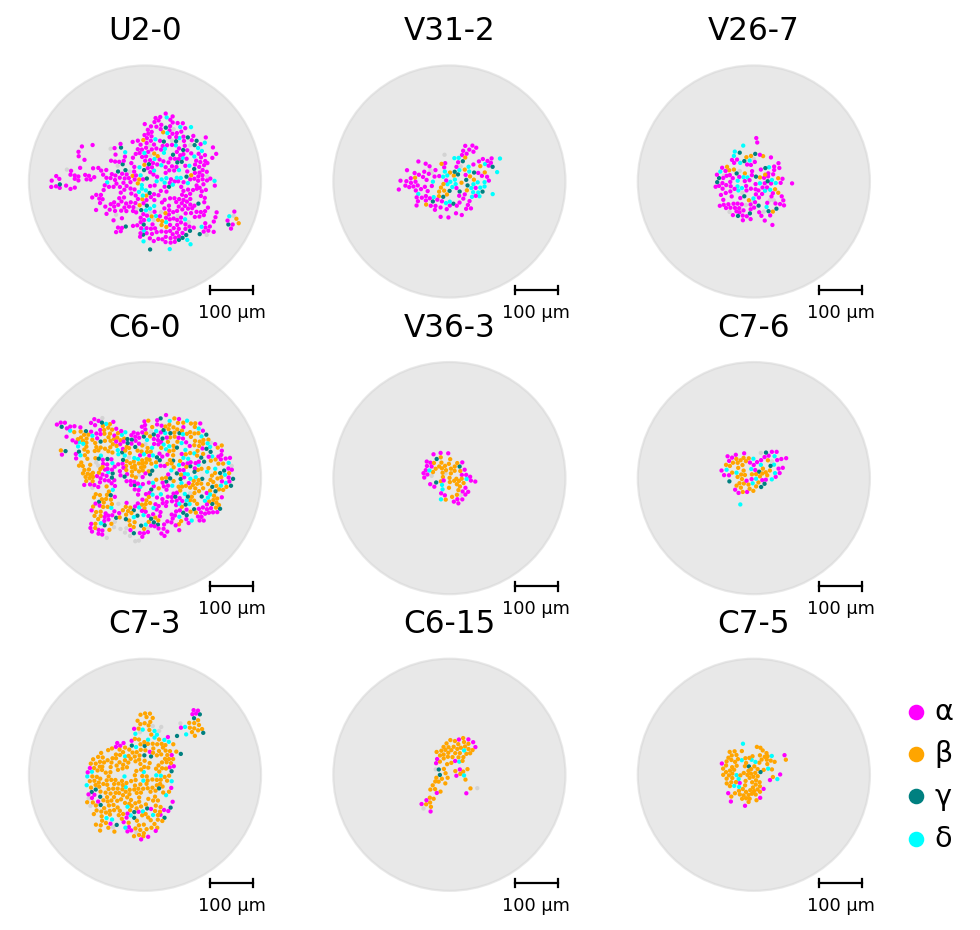

In [120]:
ist_islets = [
    # low beta fraction < 0.15
    'U2_0', 'V31_2', 'V26_7',
    # beta fraction ~ 0.5
    'C6_0', 'V36_3', 'C7_6',
    # high beta fraction
    'C7_3', 'C6_15', 'C7_5',
]
adata_islets = adata[
    (adata.obs['islets_in_out'] == 'in') &
    (adata.obs['islet'].isin(ist_islets))
].copy()
scalebar_mm = 100

# ----- fixed global palette (order matters)
label_col = 'islet_label_sharpen'
class_order = ["α", "β", "γ", "δ", "α_β"]
base_colors = {
    "α":   "#FF00FF",  # magenta
    "β":   "#FFA500",  # orange
    "γ":   "#008080",  # teal
    "δ":   "#00FFFF",  # cyan
    "α_β": "#800080",  # purple
}
# Which classes are present in this subset (preserve your desired class_order)
present = pd.Index(adata_islets.obs[label_col].dropna().unique())
cats = [c for c in class_order if c in present]
# Make the column categorical with exactly these categories
adata_islets.obs[label_col] = pd.Categorical(
    adata_islets.obs[label_col], categories=cats, ordered=False)
# Build palette aligned to category order
fallback = "#999999"
palette = [base_colors.get(c, fallback) for c in cats]
adata_islets.uns[f"{label_col}_colors"] = palette  # Scanpy will use this automatically

# ----- plotting
width, height = 600, 600

fig, axs = plt.subplots(3, 3, figsize=[7, 7])
axs = axs.ravel()
plt.subplots_adjust(wspace=0.15, hspace=0.15)

for ax, islet in zip(axs, ist_islets):
    # add gray circle
    circle = Circle(
        (0.5, 0.5),        # center of axes
        radius=0.45,        # fills the axes
        transform=ax.transAxes,  # IMPORTANT: use axes coords
        # facecolor='white',
        # edgecolor='black',
        # linewidth=1,
        color='lightgray',
        alpha=0.5,
        zorder=0
    )
    ax.add_patch(circle)

    # add islet
    sample = islet.split('_')[0]
    adata_tmp = adata_islets[
        (adata_islets.obs['islet'] == islet) &
        (~ adata_islets.obs['islet_label_sharpen'].isin(['Low quality', 'α_β']))
        ].copy()

    xmin, xmax = adata_tmp.obs['x'].min(), adata_tmp.obs['x'].max()
    ymin, ymax = adata_tmp.obs['y'].min(), adata_tmp.obs['y'].max()
    x_offset = (width - (xmax - xmin)) / 2
    y_offset = (height - (ymax - ymin)) / 2

    crop = [
        xmin - x_offset, xmax + x_offset,
        ymin - y_offset, ymax + y_offset,
    ]

    sc.pl.spatial(
        adata_tmp,
        color='islet_label_sharpen',
        ax=ax,
        show=False,
        crop_coord=crop,
        spot_size=10,
    )

    ax.axis('off')

    if ax != axs[-1]:
        ax.legend().remove()
    
    ax.set_title(islet.replace('_', '-'))

    # If your spatial coordinates are in micrometers:
    units_per_mm = 1   # 1000 um = 1 mm

    bar_len_mm = scalebar_mm
    bar_len_units = bar_len_mm * units_per_mm

    reset_xmin, reset_xmax = xmin - x_offset, xmax + x_offset
    reset_ymin, reset_ymax = ymin - y_offset, ymax + y_offset

    # data ranges
    xrange = reset_xmax - reset_xmin
    yrange = reset_ymax - reset_ymin

    # padding from plot edges
    pad_x = 0.08 * xrange
    pad_y = 0.08 * yrange

    # bottom-right position
    x1 = reset_xmax - pad_x
    x0 = x1 - bar_len_units
    y0 = reset_ymax - pad_y

    # draw bar
    ax.plot([x0, x1], [y0, y0], color="k", lw=1)
    ax.plot([x0, x0], [y0 - 10, y0 + 10], color="k", lw=1)
    ax.plot([x1, x1], [y0 - 10, y0 + 10], color="k", lw=1)

    # label below bar
    ax.text(
        (x0 + x1) / 2,
        y0 + 0.05 * yrange,
        f"{bar_len_mm:g} μm",
        ha="center",
        va="top",
        color="k",
        fontsize=8
    )
    
plt.show()

fig.savefig(
    os.path.join(fig_folder, f'islet_zoo_beta_proportions_3.png'),
    bbox_inches='tight', dpi=300
)
fig.savefig(
    os.path.join(fig_folder, f'islet_zoo_beta_proportions_3.pdf'),
    bbox_inches='tight', dpi=300
)

# alpha/beta ratio vs gene expression (spatial)

## functions

In [95]:
def get_binned_middles(x, y, n_bins=10, bin_type='number', pct_thr=0.8):
    """
    Bin x either by its value range ('number') or by fixed feature range 0–1 ('feature'),
    then compute per-bin median or mean of y.
    """
    # 1) Define bin edges
    if bin_type == 'number':
        bins = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    elif bin_type == 'feature':
        bins = np.linspace(0, 1, n_bins + 1)
    else:
        raise ValueError("bin_type must be 'number' or 'feature'")

    # 2) Bin centers for plotting
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # 3) Assign each x to a bin
    bin_idx = np.digitize(x, bins) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    # 4) Labels
    if bin_type == 'number':
        labels = []
        for i in range(n_bins):
            mask = (bin_idx == i)
            if np.any(mask):
                lo = x[mask].min()
                hi = x[mask].max()
            else:
                # empty bin → fall back to bin edges
                lo = bins[i]
                hi = bins[i + 1]
            labels.append(f"{lo * 100:.0f}-{hi * 100:.0f}%")
    else:  # 'feature'
        labels = [f"{(bins[i]*100):.0f}-{(bins[i+1]*100):.0f}%" for i in range(n_bins)]

    # 5) Decide median vs mean based on overall non-zero fraction
    if (y > 0).sum() >= pct_thr * len(y):
        agg = np.nanmedian
    else:
        agg = np.nanmean

    middles = [
        agg(y[bin_idx == i]) if np.any(bin_idx == i) else np.nan
        for i in range(n_bins)
    ]

    middles = pd.Series(middles, index=labels)
    
    return middles, bin_centers, bin_idx

def add_binned_middles(ax, x, y, n_bins=10, bin_type='number', pct_thr=0.8, cmap='Blues'):
    
    middles, bin_centers, bins = get_binned_middles(
        x, y, n_bins=n_bins, bin_type=bin_type, pct_thr=pct_thr
    )
    
    norm = plt.Normalize(np.nanmin(middles), np.nanmax(middles))
    colors = plt.cm.get_cmap(cmap)(norm(middles))
    
    ax.scatter(bin_centers, middles.values, c=colors, s=80, 
               edgecolor='k', linewidth=0.5)
    
    return bins, bin_centers, middles

## create a heatmap
def get_sig_corr_genes(ct_cpm, spatial_islet_corr, pseudo_islet_parse_res, ct, feat, 
                       exp_pct_thr=0.4, q_thr=0.1, abs_thr = 0.18, n_gs=10, mode='percentile'):
    
    # filter genes expressed more than 40% islets in the spatial data
    com_genes = ct_cpm[((ct_cpm > 0).sum(axis=1) / ct_cpm.shape[1]) >= exp_pct_thr].index.tolist()
#     com_genes = list(set(com_genes) & set(spatial_islet_corr[f'{ct}_{feat}'].index))
    com_genes = list(set(com_genes) & set(spatial_islet_corr[f'{ct}_{feat}'].index))
    
    tmp = pd.DataFrame(index=com_genes)
    tmp['Spatial'] = spatial_islet_corr[f'{ct}_{feat}'].loc[com_genes]['rho']
    tmp['Parse'] = pseudo_islet_parse_res.loc[com_genes]['rho']
    
    if mode == 'percentile':
        if ((tmp['Parse'] > 0) & (tmp['Spatial'] < 0)).sum() == 0:
            r_qth = 1
        else:
            r_qth = np.quantile(
                tmp[(tmp['Parse'] > 0) & (tmp['Spatial'] < 0)]['Spatial'], q_thr)
            
        if ((tmp['Parse'] < 0) & (tmp['Spatial'] > 0)).sum():
            l_qth = 1
        else:
            l_qth = np.quantile(
                tmp[(tmp['Parse'] < 0) & (tmp['Spatial'] > 0)]['Spatial'], 1 - q_thr)
            
    elif mode == 'rank': 
        r_qth = 0
        l_qth = 0
    else:
        raise ValueError("mode must be 'percentile' or 'rank'")
    
    # right genes
    blue_gs = tmp[
        (tmp['Spatial'] < r_qth) & (tmp['Parse'] > 0) & (tmp['Spatial'] <= -abs_thr)
    ].sort_values('Spatial')[:n_gs].index.tolist()
    
    # left genes
    red_gs = tmp[
        (tmp['Spatial'] > r_qth) & (tmp['Parse'] < 0) & (tmp['Spatial'] >= abs_thr)
    ].sort_values('Spatial', ascending=False)[:n_gs].index.tolist()

    return {'neg': blue_gs, 'pos': red_gs}


# ct_cpm = pseudo_bulk_log2.xs(ct,  level="celltype", axis=1)
def get_corr_islets(ct_cpm, features, feat, q_thr=0.01, groups=['ND-Lean']):
    ct_lean_islets = list(
        set(features[features['group'].isin(groups)].index) 
        & set(ct_cpm.columns)
    )
#     return ct_lean_islets
    orig_ct_feat = features[feat].loc[ct_lean_islets].copy()
    ql, qr = orig_ct_feat.quantile([q_thr, 1-q_thr])
    ct_filt_islets = orig_ct_feat[orig_ct_feat.between(ql, qr)].index.tolist()
    return ct_filt_islets

In [96]:
def plot_islet_sig_gs_parse_spatial_exp_vs_frac(tmp, blue_gs, red_gs, group, 
                                                marker_gs=['GCG', 'INS', 'IAPP']):
    
    ct_renames = {'alpha': 'α', 'beta': 'β', 'gamma': 'γ', 'delta': 'δ'}
    
    fig, ax = plt.subplots(figsize=[4, 4])

    x = tmp['Parse']
    y = tmp['Spatial']

    ax.scatter(x=x, y=y, s=50, alpha=0.4, edgecolor='w', linewidth=1, c='lightgray')

    x_vmax = x.abs().max()
    ax.set_xlim([- x_vmax - 0.05, x_vmax + 0.2])
    y_vmax = y.abs().max()
    ax.set_ylim([- y_vmax - 0.1, y_vmax + 0.1])

    ax.set_xlabel(fr'Spearman $\rho$' + '\n(simulated from snRNA-Seq)')
    ax.set_ylabel(fr'Spearman $\rho$' + '\n(spatial transcriptomics)')
    ax.set_title(f'Gene exp in {ct} vs {ct_renames[feat.split('_')[0]]} cell proportion')

    ax.axvline(0, c='k', ls='--', linewidth=1)
    ax.axhline(0, c='k', ls='--', linewidth=1)

    # color the genes
    ax.scatter(
        x=x.loc[blue_gs],
        y=y.loc[blue_gs],
        s=50, alpha=0.5, 
        edgecolor='w', linewidth=1,
        c='blue',
        label='Sig neg'
    )

    ax.scatter(
        x=x.loc[red_gs],
        y=y.loc[red_gs],
        s=50, alpha=0.5, 
        edgecolor='w', linewidth=1,
        c='red',
        label='Sig pos'
    )

    ax.scatter(
        x=x.loc[[g for g in marker_gs if g in tmp.index]],
        y=y.loc[[g for g in marker_gs if g in tmp.index]],
        s=50, alpha=0.5, 
        edgecolor='w', linewidth=1,
        c='k',
    )

    ax.legend(bbox_to_anchor=[1, 1])

    # add annotations to genes
    texts = []

    for gene in blue_gs + red_gs + [g for g in marker_gs if g in tmp.index]:
        texts.append(ax.text(x.loc[gene], y.loc[gene], gene, fontsize=10, color='k'))

    adjust_text(texts, expand=(1.2, 2), arrowprops=dict(arrowstyle='->', color='black'))

    plt.show()
    
    return {'fig': fig, 'ax': ax}

In [97]:
def get_sig_gs_binned_df_z(
    pseudo_bulk_log2, features, group, sp_corr_tmp,
    cts_show=['α', 'β'], 
    exp_pct_thr=0.4, q_thr=0.1, n_gs=10, mode='percentile', 
    n_ins=5, bin_type='number', 
    feat_show='beta_frac'
):

    ct_renames = {'α': 'alpha', 'β': 'beta', 'γ': 'gamma', 'δ': 'delta'}
    ct_colors = {
        "α":   "#E377C2",  # pink
        "β":   "#FF7F0E",  # orange
        'both': "grey"
    }
    type_colors = {
        "pos": 'lightcoral',
        'neg': 'steelblue'
    }

    all_gs = []
    gs_ct_colors = {}
    gs_type_colors = {}

    for ct in cts_show:
        # get basic information
        feat = f'{ct_renames[ct]}_frac'
        
        ct_cpm = pseudo_bulk_log2.xs(ct,  level="celltype", axis=1)
        ct_filt_islets = get_corr_islets(ct_cpm, features, feat, groups=[group])

        pseudo_islet_parse_res = pd.read_csv(
            os.path.join(
                res_folder,
                f'islet_analysis/{group}/parse_spearman_pseudo_islets_w_β_ratio_islet_exp_vs_{ct}_frac.tsv'
            ), sep='\t', index_col=0
        )
        ct_res = get_sig_corr_genes(ct_cpm, sp_corr_tmp, pseudo_islet_parse_res, ct, feat, 
                               exp_pct_thr=exp_pct_thr, q_thr=q_thr, n_gs=n_gs, mode=mode)
        ct_gs = ct_res['pos'] + ct_res['neg']

        all_gs += ct_gs

        for g in ct_gs:
            if g in [k[1] for k in gs_type_colors.keys()]:
                gs_ct_colors[(ct, g)] = ct_colors["both"]
                gs_ct_colors[('α', g)] = ct_colors["both"]
            else:
                gs_ct_colors[(ct, g)] = ct_colors[ct]

            if g in ct_res['pos']:
                gs_type_colors[(ct, g)] = type_colors['pos']
            else:
                gs_type_colors[(ct, g)] = type_colors['neg']

    # get the binned infomration for plotting
    binned_df_z_all = pd.DataFrame()

    for ct in cts_show:
        ct_cpm = pseudo_bulk_log2.xs(ct,  level="celltype", axis=1)
        ct_filt_islets = get_corr_islets(ct_cpm, features, feat_show, groups=[group])
        x = features.loc[ct_filt_islets][feat]

        binned_df = []
        for gene in all_gs:
            y = ct_cpm[ct_filt_islets].loc[gene]
            s, _, _ = get_binned_middles(x, y, n_bins=n_bins, bin_type=bin_type)
            s.name = gene
            binned_df.append(s)

        binned_df = pd.DataFrame(binned_df)
        binned_df_z = (binned_df
                       .sub(binned_df.mean(axis=1), axis=0)
                       .div(binned_df.std(axis=1, ddof=0), axis=0)
                      )

        binned_df_z_all = pd.concat([binned_df_z_all, binned_df_z], axis=1)

    row_colors = pd.DataFrame({'Cell type': gs_ct_colors, 'Gene type': gs_type_colors})
    binned_df_z_all.index = row_colors.index

    return binned_df_z_all, row_colors

def heatmap_expz_spatial_sig_gs_cts_to_feat(
    binned_df_z_all, row_colors, cts_show=['α', 'β'], frac_ct='β', n_bins=5
):
    ct_colors = {
        "α":   "#E377C2",  # pink
        "β":   "#FF7F0E",  # orange
        'both': "grey"
    }
    type_colors = {
        "pos": 'lightcoral',
        'neg': 'steelblue'
    }
    g = sns.clustermap(
            binned_df_z_all, cmap="coolwarm", 
            row_colors=row_colors,
            row_cluster=False, col_cluster=False,
            linewidths=0.5, vmin=-1.5, vmax=1.5,
            figsize=[2 * len(cts_show) + 1, binned_df_z_all.shape[0] * 0.18 + 1.5],
            cbar_kws={'label': 'z-score of gene exp', 'shrink':0.5},
            colors_ratio=0.04,
            dendrogram_ratio=0.01,
            cbar_pos=(0.98, 0.7, 0.03, 0.18),
    )
    ax = g.ax_heatmap

    ax.set_ylabel(None)
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels([i.get_text()[2:] for i in ax.get_yticklabels()])

    n_rows, n_cols = binned_df_z_all.shape
    row_label = row_colors.loc['α'].shape[0] if 'α' in row_colors.index else row_colors.shape[0] - row_colors.loc['β'].shape[0]
    col_label = 5

    for y in [0 + 0.05, n_rows - 0.05, row_label]:
        ax.hlines(y, xmin=0, xmax=n_cols, colors='black', linewidth=1)

    for x in [0 + 0.05, n_cols - 0.05, col_label]:
        ax.vlines(x, ymin=0, ymax=n_rows, colors='black', linewidth=1)

    from matplotlib.patches import Patch

    # --- Cell type legend (for ct_colors) ---
    ct_patches = [
        Patch(facecolor=color, edgecolor="black", label=ct_label)
        for ct_label, color in ct_colors.items()
    ]

    # --- Gene type legend (for type_colors) ---
    type_patches = [
        Patch(facecolor=color, edgecolor="black", label=type_label)
        for type_label, color in type_colors.items()
    ]

    # First legend: cell types
    leg1 = ax.legend(
        handles=ct_patches,
        title="Cell type",
        bbox_to_anchor=(1.35, 0.6),
        loc="upper left",
        borderaxespad=0.,
        frameon=False,
    )

    # Second legend: gene types
    leg2 = ax.legend(
        handles=type_patches,
        title="Gene type",
        bbox_to_anchor=(1.35, 0.4),
        loc="upper left",
        borderaxespad=0.,
        frameon=False,
    )

    # Make sure the first legend stays when the second is added
    ax.add_artist(leg1)

    ## add labels
    trans = ax.get_xaxis_transform()

    x = 0
    xloc = 0
    for i, ct in enumerate(cts_show):

        ax.annotate(
            f'{ct} exp in binned\nislets by {frac_ct} fraction', 
            xy=(i * n_bins + 2.5 , -0.24), 
            xycoords=trans, 
            ha='center', va='center')
        ax.plot([i * n_bins + 0.2, i * n_bins + 4.8], 
                [-0.2, -0.2], 
                color='k', transform=trans, clip_on=False)
        
    return g

In [98]:
def scatterplot_diff_groups_spearmanr(d_name, group1, group2, class_name, beta_corr_tmp):
    # plotting
    fig, ax = plt.subplots(figsize=[6, 5])

    ds = beta_corr_tmp[d_name]
    cmap = 'coolwarm'
    norm = plt.Normalize(ds.min(), ds.max())
    cmap_fn = plt.cm.get_cmap(cmap)
    colors = pd.Series([tuple(rgba) for rgba in cmap_fn(norm(ds))], index=beta_corr_tmp.index)

    other_gs = beta_corr_tmp[beta_corr_tmp['Source'] == 'Others'].index
    sns.scatterplot(beta_corr_tmp.loc[other_gs],
                    x=group1, y=group2, 
    #                 hue='Group', 
    #                 palette=['navy', 'orange', 'grey'], # cream, coral
    #                 hue_order=['Obese-pos', 'Obese-neg', 'Others'],
                    color=colors.loc[other_gs],
                    edgecolor='grey', linewidth=1,
                    alpha=0.7, legend=False, ax=ax)


    for source, c in zip([group1, group2, 'Both'], ['c', 'm', 'black']):
        gs = beta_corr_tmp[beta_corr_tmp['Source'] == source].index

        sns.scatterplot(beta_corr_tmp.loc[gs], # excluding V2
                    x=group1, y=group2, 
                    color=colors.loc[gs],
                    edgecolor=c, linewidth=1.5,
                    alpha=0.7, legend=False, ax=ax)

    for i in [0,]:
        ax.axvline(i, ls='--', lw=1, c='k')
    for i in [0]:
        ax.axhline(i, ls='--', lw=1, c='k')

    ax.plot([-0.45, 0.45], [-0.45, 0.45], ls='--', lw=1, c='grey')

    ax.set_xlim([-0.45, 0.45])
    ax.set_ylim([-0.45, 0.45])

    ax.set_xlabel(rf'Spearman $\rho$ (β exp vs β frac) ' + f'- {group1}')
    ax.set_ylabel(rf'Spearman $\rho$ (β exp vs β frac) ' + f'- {group2}')

    # --- custom legends ---
    handles = []
    for label, color in zip([group1, group2, 'Both'], ['c', 'm', 'black']):
        handles.append(
            Line2D([], [], 
                   marker='o',
                   markerfacecolor='white',
                   markeredgecolor=color,
                   markeredgewidth=1.5,
                   linestyle='', markersize=8, label=label)
        )
    ax.legend(handles=handles, labels=[group1, group2, 'Both'], 
              bbox_to_anchor=[1, 0.99], loc='upper left')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.5)
    cbar.set_label(rf"Spearman $\rho$ diff"+f"\n({group2} - {group1})")

    # annotate significantly changed genes
    texts = []
    for gene in beta_corr_tmp[beta_corr_tmp[class_name] != 'Others'].index:
        gx = beta_corr_tmp.loc[gene].loc[group1]
        gy = beta_corr_tmp.loc[gene].loc[group2]
        texts.append(ax.text(gx, gy, gene, fontsize=9))

    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='k', lw=0.5)) # add texts          

    # add text
    rho, P = spearmanr(
        beta_corr_tmp[group1], 
        beta_corr_tmp[group2]
    )

    text = f'ρ={rho:.2f}\nP={P:.2f}' if P > 0.01 else f'ρ={rho:.2f}\nP<0.01'

    ax.text(0.02, 0.02, text, transform=ax.transAxes, va='bottom', ha='left')
    
    return {'fig': fig, 'ax': ax}

## load spatial pseudo-bulk data per islet

In [99]:
# load the previously saved data
pseudo_bulk = pd.read_csv(
    os.path.join(res_folder, 'islet_analysis/spatial_pseudo_bulk_per_islet_ct.tsv'), 
    sep='\t', header=[0, 1], index_col=0
)

# combine islet and cell type into one signle column
pseudo_bulk_flat = pseudo_bulk.copy()
pseudo_bulk_flat.columns = [f"{i}_{ct}" for i, ct in pseudo_bulk.columns]

# normalize each ct per islet to 1e6
pseudo_bulk_cpm = pseudo_bulk.div(pseudo_bulk.sum(axis=0), axis=1) * 1e6

# remove genes that are not expressed by any islet
pseudo_bulk_cpm = pseudo_bulk_cpm[((pseudo_bulk_cpm > 0).sum(axis=1) != 0)].copy()
# log2
pseudo_bulk_log2 = np.log2(pseudo_bulk_cpm + 1)

## load spatial spearman correlation data

In [100]:
### load the previously saved data
# 'ND-Lean'
sp_corr_lean = pd.read_csv(   
    os.path.join(res_folder, f'islet_analysis/ND-Lean/spatial_spearman_islet_ct_pseudo_bulk_exp_with_ct_frac_log2cpm.tsv'), 
    sep='\t', index_col=0, header=[0, 1]
)
# ND-Obese
sp_corr_obese = pd.read_csv(   
    os.path.join(res_folder, f'islet_analysis/ND-Obese/spatial_spearman_islet_ct_pseudo_bulk_exp_with_ct_frac_log2cpm.tsv'), 
    sep='\t', index_col=0, header=[0, 1]
)
# T2D
sp_corr_t2d = pd.read_csv(   
    os.path.join(res_folder, f'islet_analysis/T2D/spatial_spearman_islet_ct_pseudo_bulk_exp_with_ct_frac_log2cpm.tsv'), 
    sep='\t', index_col=0, header=[0, 1]
)

## visualization

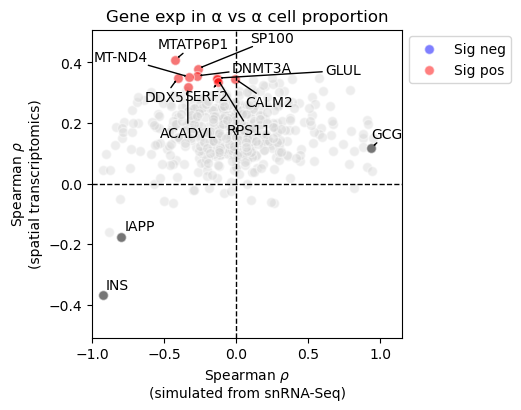

In [ ]:
# loading basic information
ct = 'α'
feat = 'alpha_frac'
exp_pct_thr=0.4
group = 'ND-Lean'
sp_corr_tmp = sp_corr_lean.copy()
mode = 'rank'

ct_cpm = pseudo_bulk_log2.xs(ct,  level="celltype", axis=1)
ct_filt_islets = get_corr_islets(ct_cpm, islet_features, feat, groups=[group])

pseudo_islet_parse_res = pd.read_csv(
    os.path.join(
        res_folder,
        f'islet_analysis/{group}/parse_spearman_pseudo_islets_w_β_ratio_islet_exp_vs_{ct}_frac.tsv'
    ), sep='\t', index_col=0
)
ct_res = get_sig_corr_genes(ct_cpm[ct_filt_islets], sp_corr_tmp, pseudo_islet_parse_res, ct, feat, 
                       exp_pct_thr=exp_pct_thr, q_thr=0.1, n_gs=10, mode=mode)
red_gs, blue_gs = ct_res['pos'], ct_res['neg']
   
# dataframe for plotting  
com_genes = ct_cpm[ct_filt_islets][
    ((ct_cpm[ct_filt_islets] > 0).sum(axis=1) / ct_cpm[ct_filt_islets].shape[1]) > exp_pct_thr
].index.tolist()
com_genes = list(set(com_genes) & set(sp_corr_tmp[f'{ct}_{feat}'].index))

tmp = pd.DataFrame(index=com_genes)
tmp['Spatial'] = sp_corr_tmp[f'{ct}_{feat}'].loc[com_genes]['rho']
tmp['Parse'] = pseudo_islet_parse_res.loc[com_genes]['rho']

fig = plot_islet_sig_gs_parse_spatial_exp_vs_frac(tmp, blue_gs, red_gs, group)['fig']

# saving figures
fig.savefig(
    os.path.join(
        fig_folder, 
        f"spatial_pseudo_islets_spearmanr_{ct}_exp_vs_{feat}_sig_gs_scatterplot.png"),
    bbox_inches='tight', dpi=300
)
fig.savefig(
    os.path.join(
        fig_folder, 
        f"spatial_pseudo_islets_spearmanr_{ct}_exp_vs_{feat}_sig_gs_scatterplot.pdf"),
    bbox_inches='tight', dpi=300
)

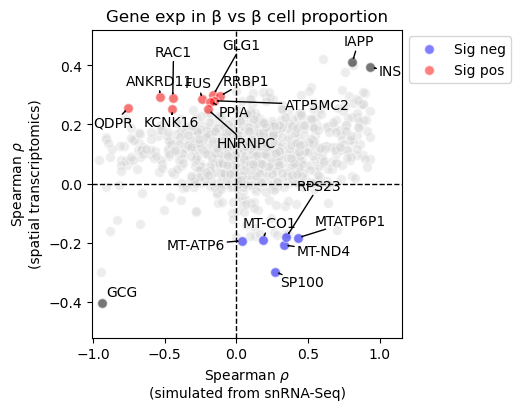

In [48]:
# loading basic information
ct = 'β'
feat = 'beta_frac'
exp_pct_thr=0.4
group = 'ND-Lean'
sp_corr_tmp = sp_corr_lean.copy()
mode = 'rank'

ct_cpm = pseudo_bulk_log2.xs(ct,  level="celltype", axis=1)
ct_filt_islets = get_corr_islets(ct_cpm, islet_features, feat, groups=[group])
# ----> that's why different feat has different islets

pseudo_islet_parse_res = pd.read_csv(
    os.path.join(
        res_folder,
        f'islet_analysis/{group}/parse_spearman_pseudo_islets_w_β_ratio_islet_exp_vs_{ct}_frac.tsv'
    ), sep='\t', index_col=0
)
ct_res = get_sig_corr_genes(
    ct_cpm[ct_filt_islets], sp_corr_tmp, pseudo_islet_parse_res, ct, feat, 
    exp_pct_thr=exp_pct_thr, q_thr=0.1, n_gs=10, mode=mode)
red_gs, blue_gs = ct_res['pos'], ct_res['neg']
   
# dataframe for plotting  
com_genes = ct_cpm[ct_filt_islets][
    ((ct_cpm[ct_filt_islets] > 0).sum(axis=1) / ct_cpm[ct_filt_islets].shape[1]) > exp_pct_thr
].index.tolist()
com_genes = list(set(com_genes) & set(sp_corr_tmp[f'{ct}_{feat}'].index))

tmp = pd.DataFrame(index=com_genes)
tmp['Spatial'] = sp_corr_tmp[f'{ct}_{feat}'].loc[com_genes]['rho']
tmp['Parse'] = pseudo_islet_parse_res.loc[com_genes]['rho']

fig = plot_islet_sig_gs_parse_spatial_exp_vs_frac(tmp, blue_gs, red_gs, group)['fig']

# saving figures
fig.savefig(
    os.path.join(
        fig_folder, 
        f"spatial_pseudo_islets_spearmanr_{ct}_exp_vs_{feat}_sig_gs_scatterplot.png"),
    bbox_inches='tight', dpi=300
)
fig.savefig(
    os.path.join(
        fig_folder, 
        f"spatial_pseudo_islets_spearmanr_{ct}_exp_vs_{feat}_sig_gs_scatterplot.pdf"),
    bbox_inches='tight', dpi=300
)

In [162]:
ct = 'β'
feat = 'beta_frac'
exp_pct_thr = 0.4
abs_thr = 0
group = 'ND-Lean'
sp_corr_tmp = sp_corr_lean.copy()
mode = 'rank'

ct_cpm = pseudo_bulk_log2.xs(ct,  level="celltype", axis=1)
ct_filt_islets = get_corr_islets(ct_cpm, islet_features, feat, groups=[group])
# ----> that's why different feat has different islets

pseudo_islet_parse_res = pd.read_csv(
    os.path.join(
        res_folder,
        f'islet_analysis/{group}/parse_spearman_pseudo_islets_w_β_ratio_islet_exp_vs_{ct}_frac.tsv'
    ), sep='\t', index_col=0
)
ct_res = get_sig_corr_genes(
    ct_cpm[ct_filt_islets], sp_corr_tmp, pseudo_islet_parse_res, ct, feat, 
    exp_pct_thr=exp_pct_thr, abs_thr=abs_thr, q_thr=0.1, n_gs=50, mode=mode)

beta_pos_genes, beta_neg_genes = ct_res['pos'], ct_res['neg']

gene_df = pd.DataFrame(columns=['pos_to_beta_ratio', 'neg_to_beta_ratio'])
gene_df['pos_to_beta_ratio'] = beta_pos_genes
gene_df['neg_to_beta_ratio'] = beta_neg_genes
gene_df.to_csv(
    os.path.join(fig_folder, 'islet_beta_ratio_top50_genes.csv'),
)

In [ ]:
gene_sets = ['GO_Biological_Process_2023', 'Reactome_Pathways_2024']
fig_FDR = 0.1
n_entities = 0

beta_ratio_top20_df = pd.DataFrame()
for pth_type, genes in zip(
    ['pos', 'neg'], 
    [beta_pos_genes, beta_neg_genes]):

    pth_res= get_pth_res(genes, gene_sets, fig_FDR, n_entities)
    pth_res['pth_type'] = pth_type
    beta_ratio_top20_df = pd.concat([beta_ratio_top20_df, pth_res])

beta_ratio_top20_df['minus_log10_fdr'] = -np.log10(beta_ratio_top20_df['Adjusted P-value'].clip(lower=1e-300))

beta_ratio_top20_df.to_csv(
    os.path.join(fig_folder, 'islet_beta_ratio_top20_genes_pathway_enrichment.csv'),
)

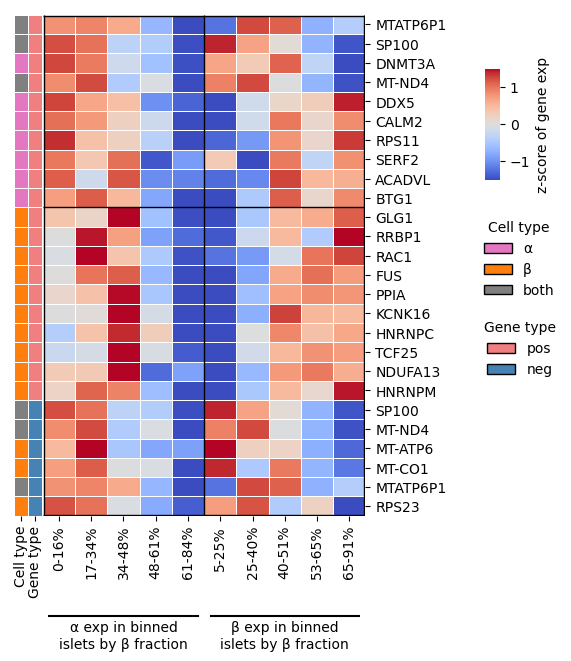

In [55]:
group = 'ND-Lean'
sp_corr_tmp = sp_corr_lean.copy()
cts_show = ['α', 'β']
exp_pct_thr=0.4
q_thr=0.1
n_gs=10
mode='rank'
n_bins = 5
bin_type = 'number'
feat_show = 'beta_frac'
frac_ct='β'

binned_df_z_all, row_colors = get_sig_gs_binned_df_z(
    pseudo_bulk_log2, islet_features, group, sp_corr_tmp,
    cts_show=cts_show, 
    exp_pct_thr=exp_pct_thr, q_thr=q_thr, n_gs=n_gs, mode=mode, 
    n_ins=n_bins, bin_type=bin_type, 
    feat_show=feat_show
)

g = heatmap_expz_spatial_sig_gs_cts_to_feat(
    binned_df_z_all, row_colors, cts_show=cts_show, frac_ct=frac_ct, n_bins=n_bins
)

# saving figures
g.figure.savefig(
    os.path.join(
        fig_folder, 
        f"spatial_ct_fraction_pseudo_islets_{n_fracs}ratios_{n_repeats}reps_sig_gs_summary_all_vs_beta_fraction_filter_by_numbers.png"),
    bbox_inches='tight', dpi=300
)
g.figure.savefig(
    os.path.join(
        fig_folder, 
        f"spatial_ct_fraction_pseudo_islets_{n_fracs}ratios_{n_repeats}reps_sig_gs_summary_all_vs_beta_fraction_filter_by_numbers.pdf"),
    bbox_inches='tight', dpi=300
)